In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datetime import datetime, timedelta
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from python_scripts.math_utils import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### <font color='yellow'> Example of simulated SGR dataset with beta distributions mixture

In [ ]:
df = simulate_SGR_dataset(n=10000)
df

,y_true,y_pred,SR
0,0,0.0,0.994084
1,1,1.0,0.972204
2,0,0.0,0.763839
3,0,0.0,0.977806
4,0,1.0,0.380255
...,...,...,...
9995,1,1.0,0.837544
9996,0,0.0,0.956362
9997,1,1.0,0.758735
9998,1,1.0,0.819119


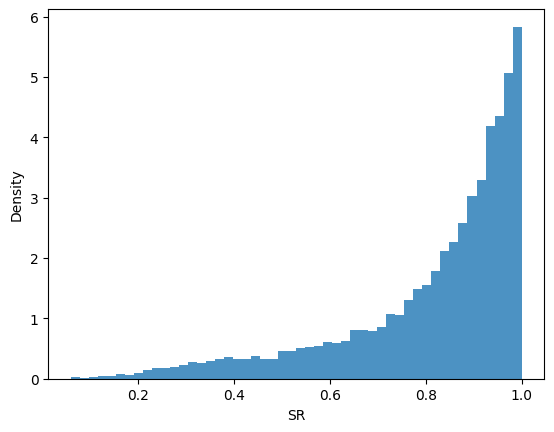

In [ ]:
plt.hist(df['SR'], bins=50, density=True, alpha=0.8)
plt.xlabel("SR")
plt.ylabel("Density")
plt.show()

C:\Users\ejeme\AppData\Local\Temp\ipykernel_7176\962436781.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mistakes_by_SR = df.groupby(pd.cut(df['SR'], bins=np.linspace(0, 1, 11)))['y_true'].apply(lambda x: (x != df.loc[x.index, 'y_pred']).mean())


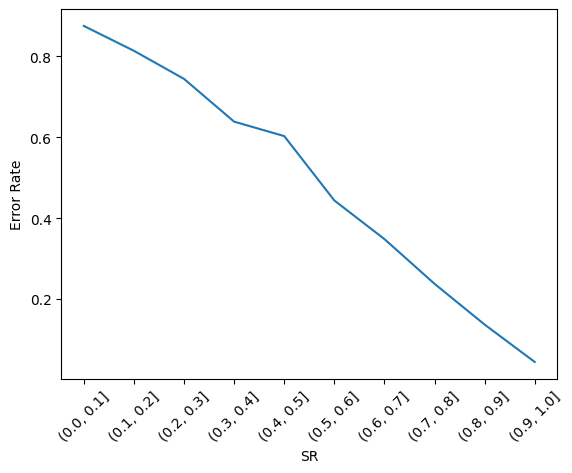

In [ ]:
mistakes_by_SR = df.groupby(pd.cut(df['SR'], bins=np.linspace(0, 1, 11)))['y_true'].apply(lambda x: (x != df.loc[x.index, 'y_pred']).mean())
plt.plot(mistakes_by_SR.index.astype(str), mistakes_by_SR)
plt.xlabel("SR")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.show()

#### <font color='yellow'> Evolution of runtime with sample size n

In [20]:
n_seed = 20
samples_sizes = [10000*i for i in range(1,11)]

In [21]:
dicos = []

for n in samples_sizes:
    times = [runtime(simulate_SGR_dataset(n=n, seed=seed)) for seed in range(n_seed)]
    quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
    dicos.append({'Search mode' : 'Dichotomy', 'n' : n, 'Runtime quantiles' : quantiles})

    for steps in [10, 20, 50]:
        times = [runtime(simulate_SGR_dataset(n=n, seed=seed), mode='greedy', greedy_steps=steps) for seed in range(n_seed)]
        quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
        dicos.append({'Search mode': 'Greedy_'+str(steps)+'_steps', 'n': n, 'Runtime quantiles' : quantiles})

In [22]:
times = pd.DataFrame(dicos)
times

,Search mode,n,Runtime quantiles
0,Dichotomy,10000,"[0.0, 0.0, 0.25]"
1,Greedy_10_steps,10000,"[1.0, 1.0, 1.0]"
2,Greedy_20_steps,10000,"[3.0, 3.0, 3.0]"
3,Greedy_50_steps,10000,"[8.0, 8.0, 8.0]"
4,Dichotomy,20000,"[1.0, 2.0, 2.0]"
5,Greedy_10_steps,20000,"[3.0, 3.0, 3.0]"
6,Greedy_20_steps,20000,"[6.0, 6.5, 7.0]"
7,Greedy_50_steps,20000,"[16.75, 17.0, 17.0]"
8,Dichotomy,30000,"[2.0, 2.0, 3.0]"
9,Greedy_10_steps,30000,"[5.0, 5.0, 5.0]"


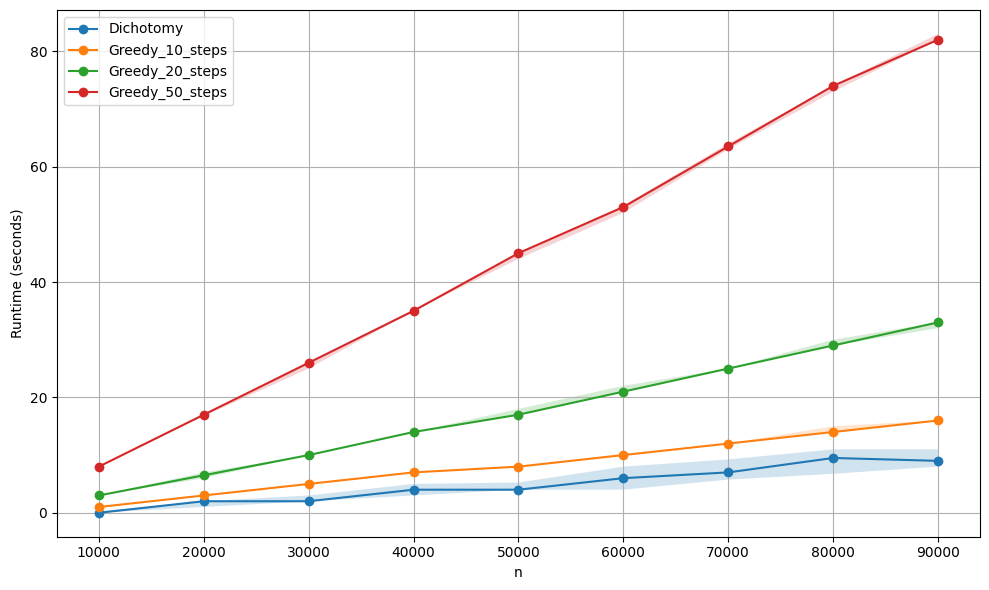

In [29]:
# Extract quantiles
times = times.copy()
times['q1'] = times['Runtime quantiles'].apply(lambda x: x[0])
times['median'] = times['Runtime quantiles'].apply(lambda x: x[1])
times['q3'] = times['Runtime quantiles'].apply(lambda x: x[2])

# Plotting
plt.figure(figsize=(10, 6))

for mode, group in times.groupby("Search mode"):
    group = group.sort_values("n")
    plt.plot(group['n'], group['median'], label=mode, marker='o')
    plt.fill_between(group['n'], group['q1'], group['q3'], alpha=0.2)

plt.xlabel("n")
plt.ylabel("Runtime (seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
